### Computational Companion to: "Characterization of $-2$-markable  Graphs"

**Authors**: Chaochui Chen, Haiying Shan, Muhuo Liu, Zoran Stanić  
**Software**: SageMath 10.5+  
**Date**: November 2025


---

 #### This code implements calculations for the paper:"Characterization of $-2$-markable  Graphs"

# The computation in Lemma 5.2

We show that the vertex-marked graph  $\mathbf{G}=\mathbf{G}(\Sigma)$ in Case 2 is an induced subgraph of one of the following five vertex-marked graphs: $\mathbf{H}_1, \mathbf{H}_2, \cdots, \mathbf{H}_5$.

**Code Logic Summary:**

This computation implements a systematic search for maximal valid subsets of root vectors that satisfy specific inner product constraints. The algorithm proceeds as follows:

1. **Root Generation**: Generate all long roots (±ei ± ej, i≠j) and short roots (1/2(±e1 ± e2 ± e3 ± e4)) in a 4-dimensional vector space over the rationals, representing the root system structure.

2. **Backtracking Search**: Use depth-first search (DFS) with backtracking to find all maximal valid subsets (R, B) where:
   - R is a set of long roots with constraints: inner products between vectors in R must be in {0, 1}
   - B is a set of short roots with constraints: inner products between vectors in B must be in {0, -1}
   - Inner products between R and B vectors must be in {0, -1}
   - Vectors that are totally orthogonal to both R and B are excluded to ensure irreducibility

3. **Graph Construction**: For each maximal subset (R, B), construct a graph G with adjacency matrix defined by: a_{ij} = χ_i · χ_j - ⟨v_i, v_j⟩ for i≠j, where χ is the indicator vector for the red set R (marked vertices), and v_i, v_j are the corresponding root vectors.

4. **Isomorphism Classification**: Extract representatives of non-isomorphic graphs under the red-blue vertex coloring, identifying the distinct vertex-marked graphs that can arise from these maximal subsets.

The five vertex-marked graphs obtained in the end are exactly the $\mathbf{H}_1, \mathbf{H}_2, \cdots, \mathbf{H}_5$ that appear in Case 2.



In [21]:
from itertools import product, chain, combinations
# Define 4-dimensional vector space
V = VectorSpace(QQ, 4)

# Basis vectors e1, e2, e3, e4
e = V.basis()

# Store results
long_roots = []      # ±ei ± ej (i ≠ j)
short_roots = []      # 1/2(±e1 ± e2 ± e3 ± e4)

# === 1. Generate long roots: ±ei ± ej (i < j to avoid duplicates)
for i in range(4):
    for j in range(i+1, 4):
        ei = e[i]
        ej = e[j]
        # All possible sign combinations
        long_roots.append( ei + ej)
        long_roots.append( ei - ej)
        long_roots.append(-ei + ej)
        long_roots.append(-ei - ej)

# === 2. Generate short roots: 1/2(±e1 ±e2 ±e3 ±e4)
for signs in product([1, -1], repeat=4):
    root = sum(s * e[i] for i, s in enumerate(signs))
    short_roots.append(root / 2)

# === Output results (optional: display first few)
print("Long roots (±ei ± ej, i≠j), total {}:".format(len(long_roots)))
print(long_roots[:6])  # Display first 6 examples

print("\nshort roots (1/2(±e1±e2±e3±e4)), total {}:".format(len(short_roots)))
print(short_roots[:6])  # Display first 6 examples


Long roots (±ei ± ej, i≠j), total 24:
[(1, 1, 0, 0), (1, -1, 0, 0), (-1, 1, 0, 0), (-1, -1, 0, 0), (1, 0, 1, 0), (1, 0, -1, 0)]

short roots (1/2(±e1±e2±e3±e4)), total 16:
[(1/2, 1/2, 1/2, 1/2), (1/2, 1/2, 1/2, -1/2), (1/2, 1/2, -1/2, 1/2), (1/2, 1/2, -1/2, -1/2), (1/2, -1/2, 1/2, 1/2), (1/2, -1/2, 1/2, -1/2)]


In [22]:
# Set vectors to be immutable
for v in long_roots:
    v.set_immutable()
for v in short_roots:
    v.set_immutable()

# Helper function to check if the inner product of a vector with every vector in a set is within allowed values
def is_valid_addition(new_vec, current_set, target_values):
    """
    Check if the inner product of new_vec with every vector in current_set is in target_values.
    Returns: (bool, all_zero)
    all_zero: True if new_vec is orthogonal to all vectors in current_set (and so is not irreducible).
    """
    all_zero = True
    for v in current_set:
        ip = new_vec.dot_product(v)
        if ip not in target_values:
            return False, False
        if ip != 0:
            all_zero = False
    return True, all_zero
    
# Main search function (backtracking)
maximal_sets = []

# Use a stack for DFS: each element is (R, B, remaining_long, remaining_short)
# Initialize: starting sets, all vectors are initially available
initial_R = [long_roots[0]] # The long root e1+e2
initial_B = [short_roots[-1]] # The short root -1/2(e1+e2+e3+e4)
remaining_long = long_roots[:]
remaining_short = short_roots[:]

stack = [(initial_R, initial_B, remaining_long, remaining_short)]

# To avoid duplicates, use a tuple (set_R, set_B) as a key in a set
seen = set()


    
while stack:
    R, B, rem_long, rem_short = stack.pop()

    # Try to add each remaining vector (either to R or B)
    can_add = False

    # Try adding 'long' vectors to R
    for v in rem_long:
        valid_R, all_zero_R = is_valid_addition(v, R, {0, 1})
        if not valid_R:
            continue
        valid_B, all_zero_B = is_valid_addition(v, B, {0, -1})
        if not valid_B:
            continue

        # Forbid adding if v is totally orthogonal to both R and B
        if all_zero_R and all_zero_B:
            continue
        

        can_add = True
        new_R = R + [v]
        new_rem = [w for w in rem_long if w != v]
        stack.append((new_R, B, new_rem, rem_short[:]))

    # Try adding 'short' vectors to B
    for v in rem_short:
        valid_B, all_zero_B = is_valid_addition(v, B, {0, -1})
        if not valid_B:
            continue
        valid_R, all_zero_R = is_valid_addition(v, R, {0, -1})
        if not valid_R:
            continue

        # Forbid adding if v is totally orthogonal to both R and B
        if all_zero_R and all_zero_B:
            continue

        can_add = True
        new_B = B + [v]
        new_rem = [w for w in rem_short if w != v]
        stack.append((R, new_B, rem_long[:], new_rem))

    # If no more vectors can be added, this is a maximal subset
    if not can_add:
        # Normalize R and B for deduplication: sort by string and use as tuple
        sorted_R = tuple(sorted(R, key=str))
        sorted_B = tuple(sorted(B, key=str))
        key = (sorted_R, sorted_B)
        if key not in seen:
            seen.add(key)
            maximal_sets.append((R[:], B[:]))
            print(f"Found maximal subset: |R|={len(R)}, |B|={len(B)}, total={len(R)+len(B)}")
print(f"Total number of maximal valid subsets found: {len(maximal_sets)}")

Found maximal subset: |R|=6, |B|=4, total=10
Found maximal subset: |R|=5, |B|=3, total=8
Found maximal subset: |R|=6, |B|=4, total=10
Found maximal subset: |R|=5, |B|=3, total=8
Found maximal subset: |R|=5, |B|=3, total=8
Found maximal subset: |R|=5, |B|=3, total=8
Found maximal subset: |R|=5, |B|=2, total=7
Found maximal subset: |R|=5, |B|=2, total=7
Found maximal subset: |R|=5, |B|=3, total=8
Found maximal subset: |R|=6, |B|=4, total=10
Found maximal subset: |R|=5, |B|=3, total=8
Found maximal subset: |R|=5, |B|=3, total=8
Found maximal subset: |R|=5, |B|=2, total=7
Found maximal subset: |R|=5, |B|=3, total=8
Found maximal subset: |R|=5, |B|=2, total=7
Found maximal subset: |R|=5, |B|=3, total=8
Found maximal subset: |R|=5, |B|=3, total=8
Found maximal subset: |R|=5, |B|=3, total=8
Found maximal subset: |R|=6, |B|=4, total=10
Found maximal subset: |R|=5, |B|=3, total=8
Found maximal subset: |R|=5, |B|=3, total=8
Found maximal subset: |R|=5, |B|=2, total=7
Found maximal subset: |R|=5,

In [23]:
def construct_graph_from_subset(R, B):
    """
    Given red set R and blue set B, construct the matrix AG and treat it as the adjacency matrix of a graph.
    Matrix AG is constructed as follows:
    - The index set is {1, ..., n}, where elements of R come first (total |R|), followed by elements of B (total |B|).
    - R corresponds to the marked set S (i.e., the first |R| indices)
    - a_{ij} = chi_i * chi_j - <vectors[i], vectors[j]>, if i != j
    - a_{ij} = 0, if i == j
    where chi[i] = 1 if i is from R (the first |R| elements), otherwise chi[i] = 0.

    Returns the graph G with adjacency matrix AG.
    """
    vectors = R + B
    n = len(vectors)
    r_len = len(R)  # |R|, the first r_len elements belong to S

    # 1. Construct indicator vector chi (n x 1 column vector)
    chi = vector(ZZ, [1 if i < r_len else 0 for i in range(n)])

    # 2. Construct adjacency matrix A(G)
    AG = matrix(ZZ, n, n)  # Use integer matrix, since results should be integer

    for i in range(n):
        for j in range(n):
            if i == j:
                AG[i, j] = 0  # Diagonal is zero
            else:
                # Compute a_{ij} as defined
                AG[i, j] = chi[i] * chi[j] - vectors[i].dot_product(vectors[j])

    # 3. Construct graph
    G = Graph(AG, format='adjacency_matrix')

    # 4. Return graph
    return G

In [24]:
"""
Extract representatives of non-isomorphic graphs under red-blue coloring from maximal_sets.

Args:
    maximal_sets: List of tuples (R, B), where R and B are lists of vectors.
    construct_graph_from_subset: Function, takes R, B as input and outputs G.

Returns:
    iso_maximal_graphs: List of [G_canon, partition],
                        where G_canon is the canonical labeled graph,
                        and partition is [[red], [blue]]
"""
iso_maximal_graphs = []  # Stores representatives of non-isomorphic graphs under coloring

for maximal_set in maximal_sets:
    R = maximal_set[0]
    B = maximal_set[1]
    r = len(R)
    b = len(B)
    red_indices = list(range(r))
    blue_indices = list(range(r, r + b))
    partition = [red_indices, blue_indices]  # [[red], [blue]]

    # Construct the original graph structure
    G = construct_graph_from_subset(R, B)

    # Compute the canonical labeled graph under the colored partition
    G_canon = G.canonical_label(partition=partition)

    # Get the graph6 encoding of the canonical graph (for deduplication)
    key = G_canon.graph6_string()

    # Check if an isomorphic graph already exists
    found = False
    for existing_G, existing_p in iso_maximal_graphs:
        if existing_G.graph6_string() == key and existing_p == partition:
            found = True
            break

    # If not found, add it to the list
    if not found:
        iso_maximal_graphs.append([G_canon, partition])

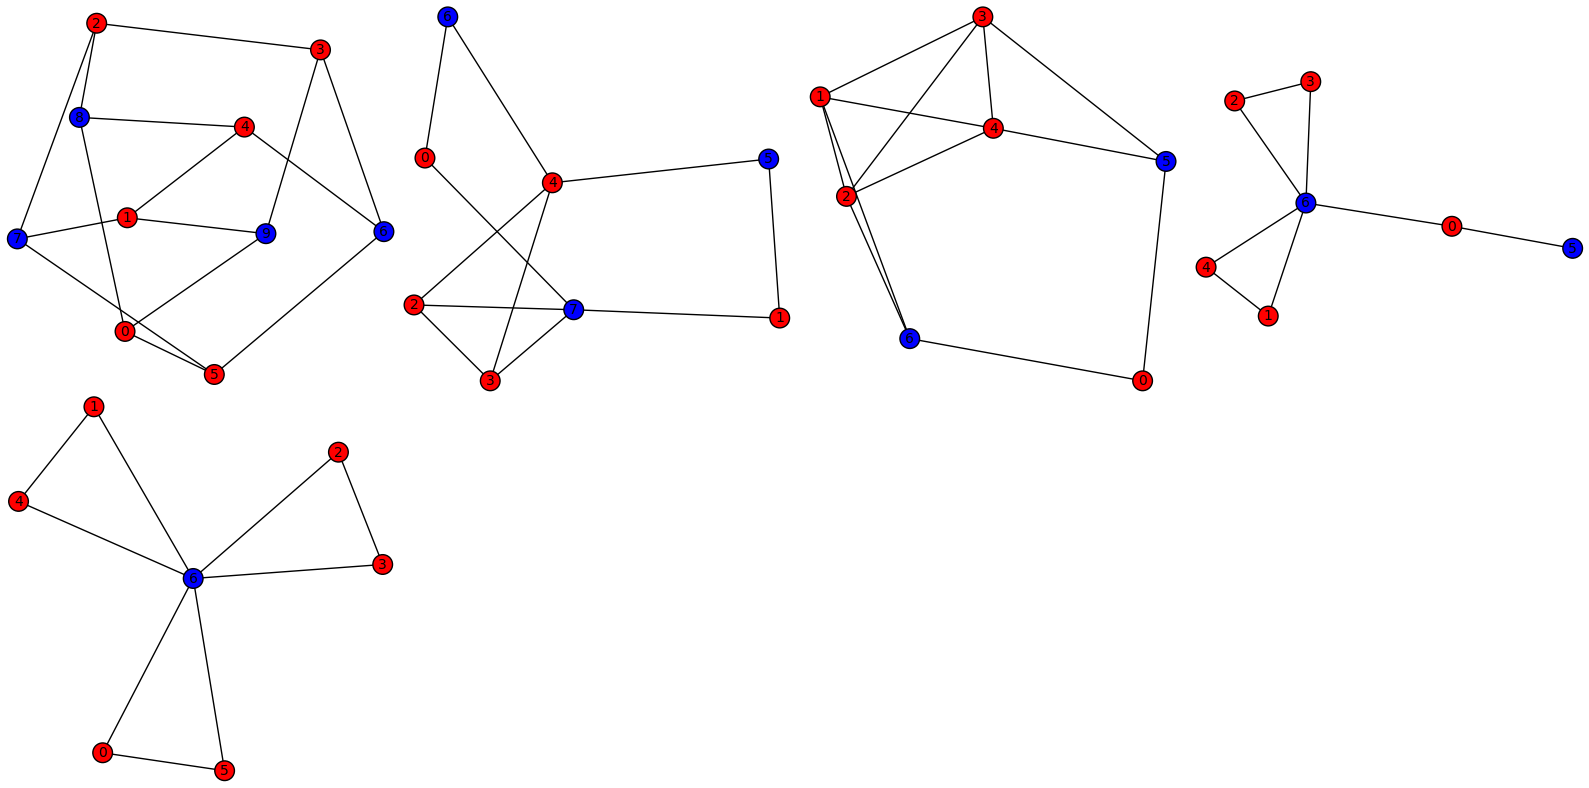

In [25]:
# Draw the resulting vertex-marked graphs
# Display 4 graphs per row
n_per_row = 4
graphplot = [maximal_graph[0].plot(vertex_colors={
        'red': maximal_graph[1][0],
        'blue': maximal_graph[1][1]
    }) for maximal_graph in iso_maximal_graphs]

# Group the list into sublists, 4 per group (for rows)
rows = [graphplot[i:i+n_per_row] for i in range(0, len(graphplot), n_per_row)]

# Pad the last row
for row in rows:
    while len(row) < n_per_row:
        row.append(Graph().plot())  # Use an empty plot as a placeholder

# Create graphics array
G_array = graphics_array(rows)

# Show the entire array (overall figsize can be specified)
G_array.show(figsize=[16, 4*len(rows)])  # width 16, height 4 per row

# The computation in Section 6

We show that there are exactly 2182 connected graphs of order 8 satisfying $\lambda_2 \leq 1$. Among them, 1731 (approximately 79.3\%) have complements with smallest eigenvalue at least $-2$, and 2132 (approximately 97.7\%) are $-2$-markable.

In [ ]:
def is_eig_2_not_exceeding_1(G):
    """
    Determines if the second largest eigenvalue of a graph G does not exceed 1.

    Mathematical explanation:
    The second largest eigenvalue of a symmetric matrix does not exceed 1 if and only if the characteristic polynomial has at most one real root in the interval (1, +∞).

    Parameters:
    G: A graph (its adjacency matrix is a real symmetric matrix)

    Returns:
    bool: True if the second largest eigenvalue ≤ 1, False otherwise
    """
    # number_of_roots_in_interval(a, b) returns the number of real roots of the characteristic polynomial in the interval [a, b]
    f = G.charpoly('x')
    return f.number_of_roots_in_interval(1, +Infinity) - (f(1) == 0) <= 1

def is_eig_min_at_least_neg_2(G):
    """
    Determines if the smallest eigenvalue of a graph (or a real symmetric matrix) G is at least -2.

    Mathematical explanation:
    The smallest eigenvalue of a real symmetric matrix is at least -2 if and only if the characteristic polynomial has no real roots in the interval (-∞, -2).

    Parameters:
    G: A graph or real symmetric matrix

    Returns:
    bool: True if the smallest eigenvalue ≥ -2, False otherwise
    """
    # number_of_roots_in_interval(a, b) returns the number of real roots of the characteristic polynomial in the interval [a, b]
    f = G.charpoly('x')
    return f.number_of_roots_in_interval(-Infinity, -2) - (f(-2) == 0) == 0

def K(G, S):
    """
    Calculate the matrix K = Chi_S*Chi_S^T - A - I,
    where Chi_S is the indicator column vector of subset S.
    """
    A = G.adjacency_matrix()
    n = A.nrows()
    # Chi_S is an n x 1 column vector. Entry is 1 if index is in S, else 0.
    Chi_S = matrix([[1] if i in S else [0] for i in range(n)])
    # K is the matrix being checked: K = Chi_S * Chi_S^T - A - I
    K = Chi_S * Chi_S.transpose() - A - identity_matrix(n)
    return K


def all_subsets(iterable):
    """
    Return all subsets (the powerset) of elements in the iterable.
    """
    s = list(iterable)
    return chain.from_iterable(combinations(s, r) for r in range(len(s)+1))

def is_negative_2_markable(G):
    """
    Check if there exists a subset S of vertices such that the smallest eigenvalue
    of the corresponding K matrix is at least -2.
    """
    n = G.num_verts()
    vertices = list(range(n))
    # Try every subset S of vertices.
    for subset in all_subsets(vertices):
        if is_eig_min_at_least_neg_2(K(G, list(subset))):
            return True    
    return False

In [13]:
# Find all connected graphs with 8 vertices such that their second largest eigenvalue is at most 1.
result_second_largest_eigenvalue_at_most_1 = []
# Among graphs in result_second_largest_eigenvalue_at_most_1, store those whose complement's minimum eigenvalue is at least -2 in result_complement,
# and those which are -2-markable (by the defined test) in result_negative_2_markable.
result_complement = []
result_negative_2_markable = []
for G in graphs.nauty_geng("8 -c"):
    if is_eig_2_not_exceeding_1(G) is True:
        result_second_largest_eigenvalue_at_most_1.append(G)
        # If the complement of G has minimum eigenvalue at least -2, add G to both result_complement and result_negative_2_markable
        if is_eig_min_at_least_neg_2(G.complement()) is True:
            result_complement.append(G)
            result_negative_2_markable.append(G)
            continue
        # Otherwise, if G is -2-markable, add it only to result_negative_2_markable
        if is_negative_2_markable(G) is True:
            result_negative_2_markable.append(G)
print("Number of connected graphs with 8 vertices whose second largest eigenvalue does not exceed 1: {}".format(len(result_second_largest_eigenvalue_at_most_1)))
print("Number of such graphs whose complement's minimum eigenvalue is at least -2: {}".format(len(result_complement)))
print("Number of such graphs that are -2-markable: {}".format(len(result_negative_2_markable)))

Number of connected graphs with 8 vertices whose second largest eigenvalue does not exceed 1: 2182
Number of such graphs whose complement's minimum eigenvalue is at least -2: 1731
Number of such graphs that are -2-markable: 2132
